<a href="https://colab.research.google.com/github/Vithya-Sree/Social-Media-Engagement-Analytics-using-Python/blob/main/SOCIAL_MEDIA_ENGAGEMENT_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SOCIAL MEDIA ENGAGEMENT ANALYTICS USING PYTHON

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Task 1 - Data Import & Setup

In [2]:
# import CSV using pandas
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("social_media_engagement_5000.csv")

Saving social_media_engagement_5000.csv to social_media_engagement_5000 (4).csv


DATA OVERVIEW

In [3]:
print(df.shape)

(5000, 19)


In [4]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [5]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [6]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')


In [7]:
print(df.dtypes)

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [9]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


CONVERT DATA TYPES

In [10]:
# Check columns
print(df.columns.tolist())


['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


In [11]:
# Convert date
df["posted_at"] = pd.to_datetime(
    df["posted_at"],
    errors="coerce",
    dayfirst=True
)

In [12]:
print(df["posted_at"].dtype)

datetime64[ns]


In [13]:
# Convert numeric columns

numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData types after conversion:")
print(df.dtypes)


Data types after conversion:
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object


## Task 2 - Data Cleaning


CHECK MISSING VALUES

In [14]:
print(df.isnull().sum())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [15]:
# Filling missing numeric values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [16]:
# Fill missing categorical values with mode

categorical_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "is_verified",
    "device_type",
    "sentiment",
    "hashtags"
]

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


Duplicate Handling

In [18]:
# check duplicates
print(df.duplicated().sum())

0


Data Formatting

In [19]:
# Remove extra spaces

text_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

Standardize categories (

In [20]:
print(df["gender"].unique())

['female' 'male' 'other']


In [21]:
# Standardize gender
df["gender"] = df["gender"].replace({
    "m": "male",
    "f": "female",
    "male": "male",
    "female": "female",
    "other": "other"
})

In [22]:
print(df["gender"].value_counts())

gender
male      1849
other     1581
female    1570
Name: count, dtype: int64


In [23]:
print(df["sentiment"].unique())

['negative' 'positive' 'neutral']


In [24]:
# Standardize sentiment
df["sentiment"] = df["sentiment"].replace({
    "pos": "positive",
    "positive": "positive",
    "neg": "negative",
    "negative": "negative",
    "neu": "neutral",
    "neutral": "neutral"
})

In [25]:
print(df["sentiment"].value_counts())

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


HANDLE UNREALISTIC VALUES

In [26]:
# Negative likes, comments and shares are not possible
for col in ["likes", "comments", "shares"]:
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())

HASHTAG COUNT

In [27]:
df["hashtag_count"] = (
    df["hashtags"]
    .fillna("")
    .astype(str)
    .apply(
        lambda x: len(
            [tag for tag in x.split() if tag.startswith("#")]
        )
    )
)

display(df[["hashtags", "hashtag_count"]].head())

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


# Task 3 - Data Exploration

CORRELATION MATRIX

In [28]:
numeric_data = df.select_dtypes(include=np.number)

correlation = numeric_data.corr()

print("\nCorrelation Matrix:")
display(correlation)


Correlation Matrix:


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


GROUPBY ANALYSIS

In [29]:
print("\nAverage Likes by Post Type:")
display(
    df.groupby("post_type")["likes"]
    .mean()
    .sort_values(ascending=False)
)


Average Likes by Post Type:


,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [30]:
print("\nAverage Engagement Rate by Category:")
display(
    df.groupby("post_category")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)



Average Engagement Rate by Category:


,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


In [31]:
print("\nAverage Engagement Rate by Country:")
display(
    df.groupby("country")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)


Average Engagement Rate by Country:


,engagement_rate
country,
brazil,1.540704
australia,1.324339
france,1.146402
uae,1.112352
canada,0.916659
uk,0.850966
japan,0.769623
germany,0.759000
india,0.655005


In [32]:
print("\nAverage Impressions by Country:")
display(
    df.groupby("country")["impression_count"]
    .mean()
    .sort_values(ascending=False)
)


Average Impressions by Country:


,impression_count
country,
india,52462.386916
france,51727.673387
usa,51263.872255
uk,51119.393509
japan,49616.135593
brazil,49193.174603
uae,48928.413519
canada,48703.150097
germany,48605.406122


In [33]:
print("\nAverage Engagement Rate by Sentiment:")
display(
    df.groupby("sentiment")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)


Average Engagement Rate by Sentiment:


,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.919744


# Task 4 - Data Wrangling

Combine DataFrames

In [34]:
user_cols = ["user_id", "age", "gender", "country", "follower_count", "is_verified"]
post_cols = [
    "user_id",
    "post_id",
    "post_type",
    "post_category",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "posted_at",
    "device_type",
    "sentiment",
    "hashtags",
    "engagement_rate",
]

# Separate into two logical tables and drop duplicates from the user table
df_users = df[user_cols].drop_duplicates(subset=["user_id"])
df_posts = df[post_cols]

In [35]:
# Combine them back using a relational merge on 'user_id'
df_wrangled = pd.merge(df_posts, df_users, on="user_id", how="left")

Create New Fields

In [36]:
#Engagement Score: Combined total interactions per post
df_wrangled["engagement_score"] = (
    df_wrangled["likes"] + df_wrangled["comments"] + df_wrangled["shares"]
)

In [37]:
#Log-Transformed Metrics
df_wrangled["log_impression_count"] = np.log1p(df_wrangled["impression_count"])
df_wrangled["log_watch_time"] = np.log1p(df_wrangled["watch_time_sec"])


In [38]:
# Hashtag Count:
df_wrangled["hashtag_count"] = df_wrangled["hashtags"].apply(
    lambda x: len([tag for tag in str(x).split(" ") if tag.startswith("#")])
    if pd.notna(x)
    else 0
)

In [39]:
# Groupby Summary by 'post_type'
summary_post_type = (
    df_wrangled.groupby("post_type")[
        ["engagement_rate", "engagement_score", "watch_time_sec"]
    ]
    .mean()
    .reset_index()
)

In [40]:
# Groupby Summary by 'country'
summary_country = (
    df_wrangled.groupby("country")[
        ["impression_count", "engagement_score", "follower_count"]
    ]
    .mean()
    .reset_index()
)

In [41]:
# Groupby Summary by 'sentiment'
summary_sentiment = (
    df_wrangled.groupby("sentiment")[
        ["likes", "comments", "shares", "engagement_score"]
    ]
    .mean()
    .reset_index()
)

# Task 5 - STATISTICAL ANALYSIS

In [42]:
stats_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

stats = df[stats_columns]

print("\nMEAN:")
display(stats.mean())

print("\nMEDIAN:")
display(stats.median())

print("\nMODE:")
display(stats.mode().iloc[0])

print("\nSTANDARD DEVIATION:")
display(stats.std())

print("\nVARIANCE:")
display(stats.var())

print("\nPERCENTILES:")
display(stats.quantile([0.25, 0.50, 0.75]))

print("\nCOMPLETE STATISTICAL SUMMARY:")
display(stats.describe())


MEAN:


,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800



MEDIAN:


,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000



MODE:


...

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10



PERCENTILES:


,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25



COMPLETE STATISTICAL SUMMARY:


,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
count,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000
mean,10106.997400,1502.039800,1002.9106,4014.503200,0.964356,393698.224800
std,5702.293017,856.393312,570.8552,2308.096459,5.318029,230927.884535
min,10.000000,0.000000,0.0000,0.000000,0.006363,87.000000
25%,5235.000000,792.000000,511.0000,2017.750000,0.145781,194480.000000
50%,10105.500000,1497.000000,1012.0000,4034.500000,0.253896,388982.000000
75%,14959.000000,2235.250000,1483.0000,6020.250000,0.504794,589744.250000
max,19998.000000,2999.000000,1999.0000,7998.000000,191.504348,799533.000000


In [43]:
sns.set_theme(style="whitegrid")

# Task 6 - Data Visualization

### MATPLOTLIB

SCATTER
Likes vs Impressions

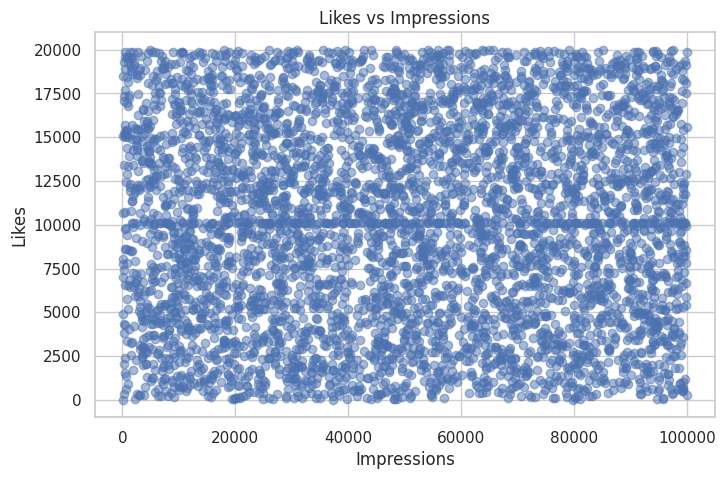

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["impression_count"],
    df["likes"],
    alpha=0.5
)

plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")

plt.show()

line : DAILY ENGAGEMENT TREND

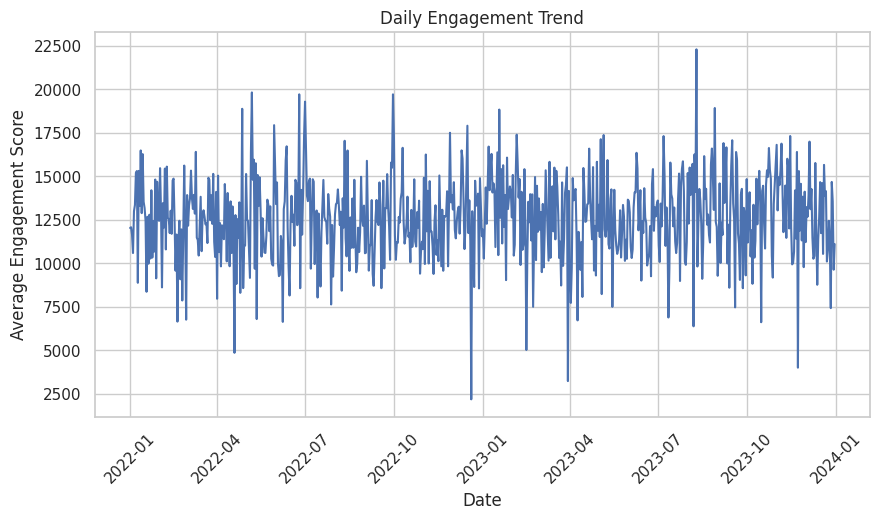

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to datetime and extract the date
df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")
df["post_date"] = df["posted_at"].dt.date

# Calculate engagement score if not already done
if "engagement_score" not in df.columns:
    df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

# Calculate daily averages
daily_engagement = df.groupby("post_date")["engagement_score"].mean().sort_index()

# Plot the trend
plt.figure(figsize=(10, 5))
plt.plot(daily_engagement.index, daily_engagement.values)

plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.title("Daily Engagement Trend")
plt.xticks(rotation=45)

plt.show()


Bar : POSTS BY CATEGORY

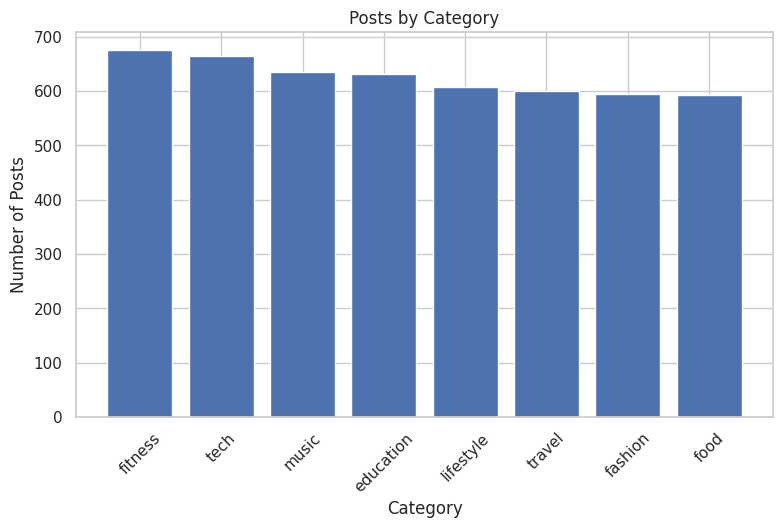

In [46]:
category_count = df["post_category"].value_counts()

plt.figure(figsize=(9, 5))

plt.bar(
    category_count.index,
    category_count.values
)

plt.xlabel("Category")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")

plt.xticks(rotation=45)

plt.show()

Pie : GENDER distribution

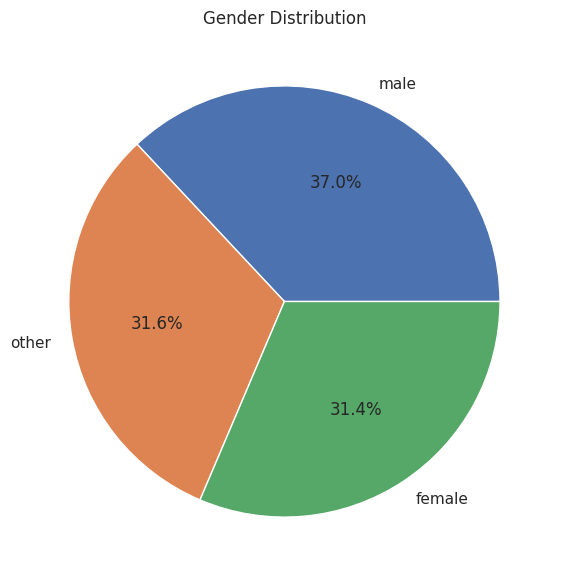

In [47]:
gender_count = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

HISTOGRAM : Age

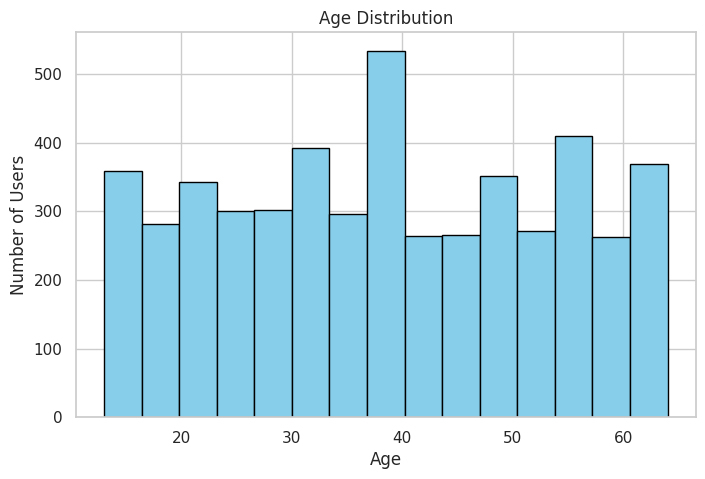

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["age"],
    bins=15,
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Age Distribution")

plt.show()

ENGAGEMENT RATE BOX PLOT


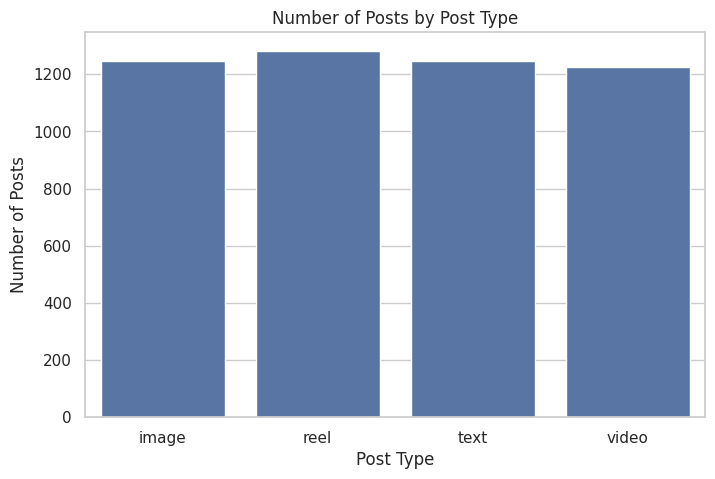

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="post_type"
)

plt.title("Number of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")

plt.show()

### SEABORN

COUNT PLOT
Post Type

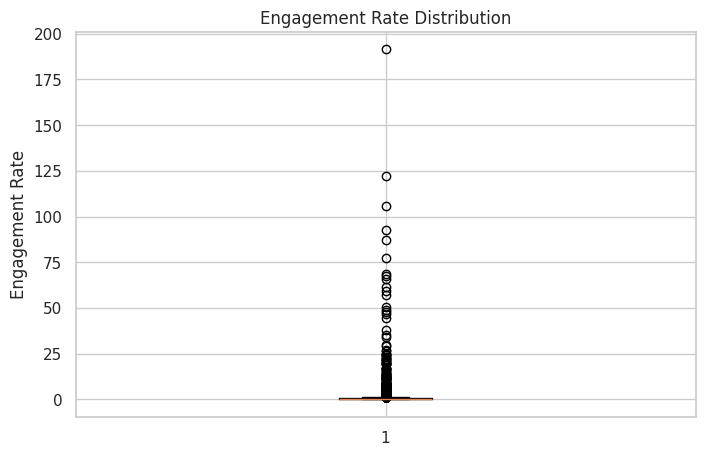

In [50]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["engagement_rate"]
)

plt.ylabel("Engagement Rate")
plt.title("Engagement Rate Distribution")

plt.show()

BAR PLOT
Average Likes by Category

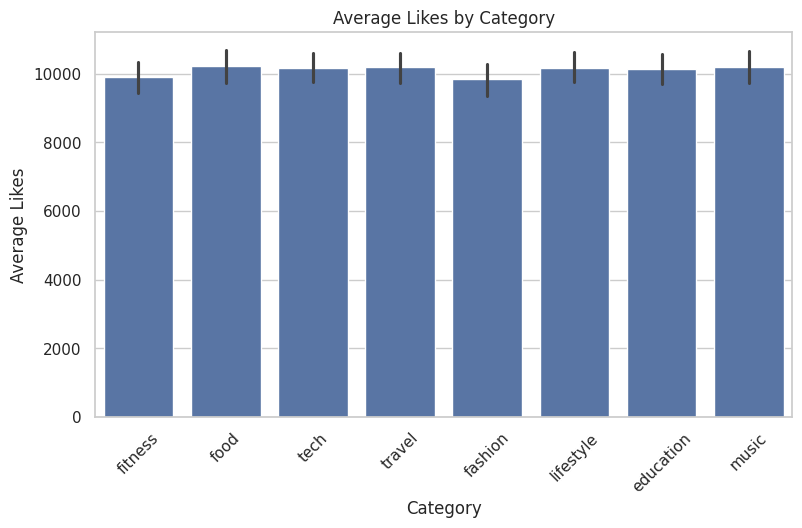

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes"
)

plt.title("Average Likes by Category")
plt.xlabel("Category")
plt.ylabel("Average Likes")

plt.xticks(rotation=45)

plt.show()

VIOLIN PLOT
Followers vs Sentiment

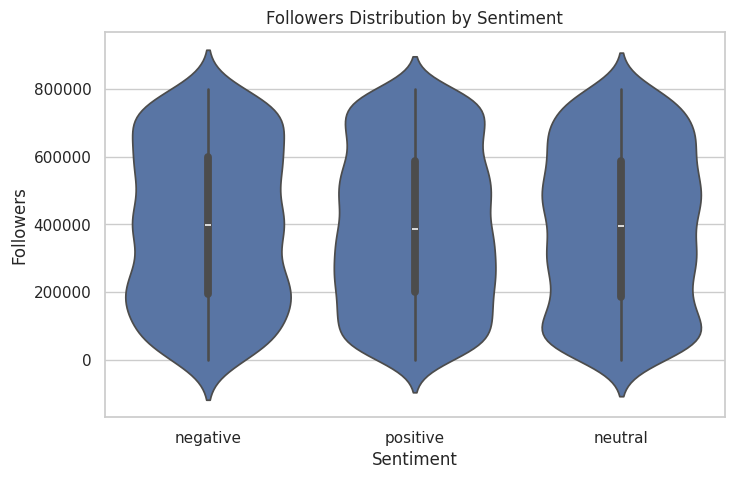

In [52]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Followers Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Followers")

plt.show()


PAIR PLOT

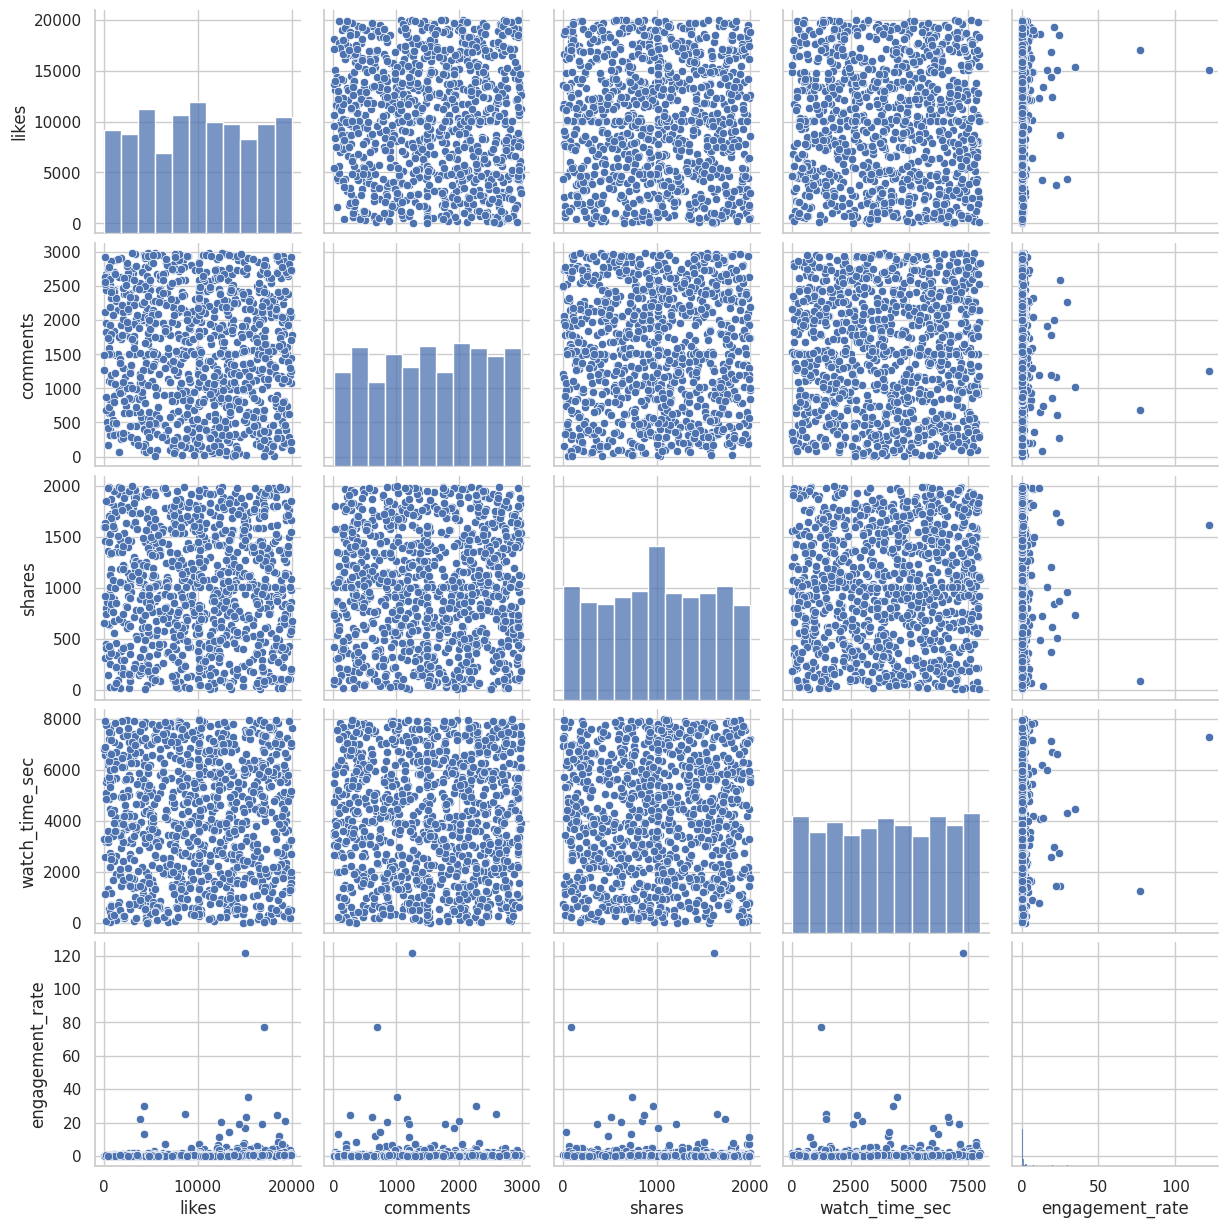

In [53]:
sample_data = df.sample(
    min(1000, len(df)),
    random_state=42
)

sns.pairplot(
    sample_data[
        [
            "likes",
            "comments",
            "shares",
            "watch_time_sec",
            "engagement_rate"
        ]
    ]
)

plt.show()

HEATMAP

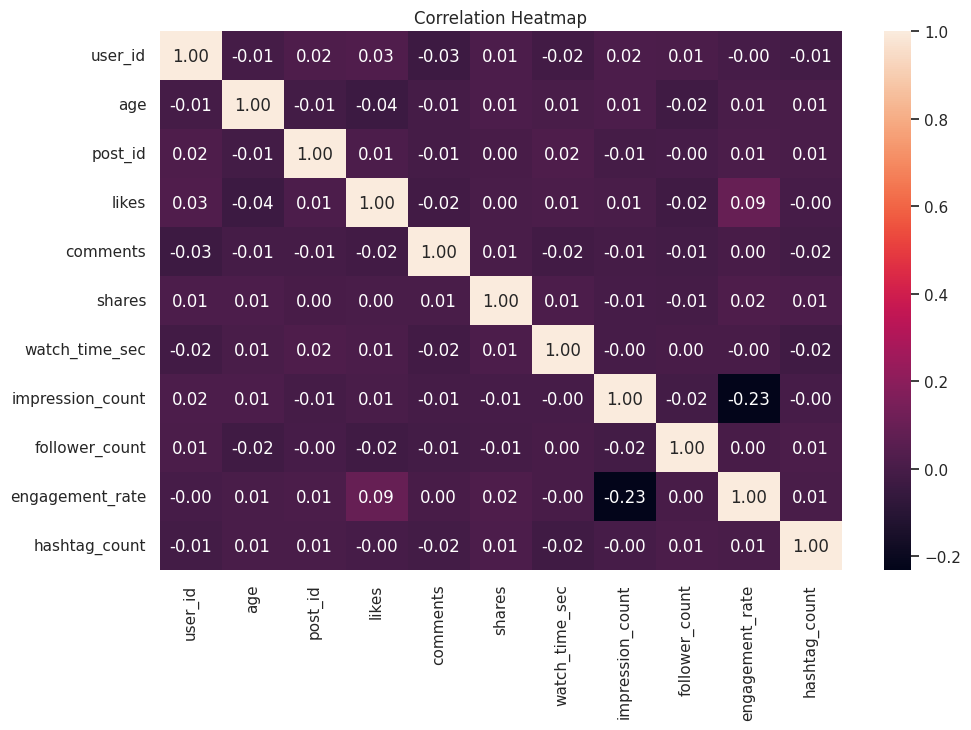

In [54]:
plt.figure(figsize=(11, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


SWARM PLOT
Engagement Rate vs Device

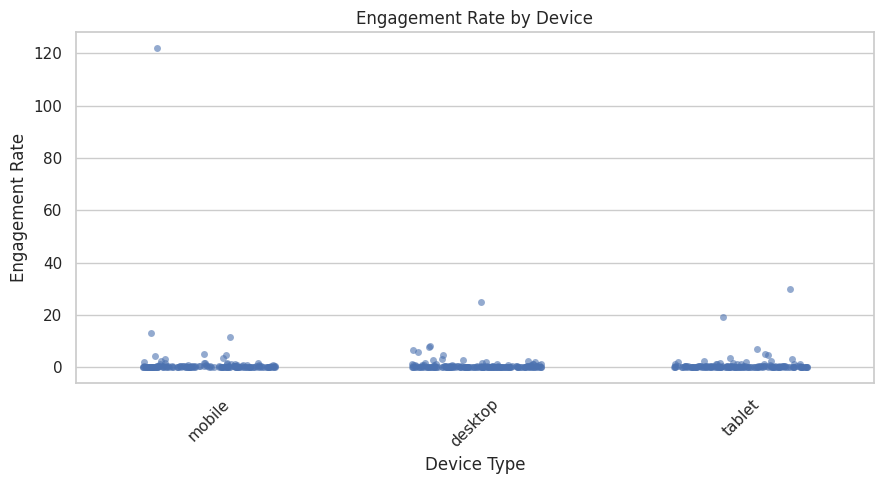

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the sample data exists and uses the correct column name
swarm_data = df.sample(min(500, len(df)), random_state=42)

plt.figure(figsize=(9, 5))

sns.stripplot(
    data=swarm_data,
    x="device_type",
    y="engagement_rate",
    jitter=0.25,
    alpha=0.6,
    size=5
)

plt.title("Engagement Rate by Device")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


PLOTLY - INTERACTIVE LINE CHART

In [57]:
import plotly.express as px
import pandas as pd

# Convert to datetime and extract the date
df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")
df["post_date"] = df["posted_at"].dt.date

# Calculate engagement score if not already done
if "engagement_score" not in df.columns:
    df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

# Calculate daily averages and sort by date
daily_plotly = (
    df.groupby("post_date")["engagement_score"]
    .mean()
    .reset_index()
    .sort_values("post_date")
)

# Plot the interactive trend
fig = px.line(
    daily_plotly,
    x="post_date",
    y="engagement_score",
    title="Interactive Daily Engagement Trend",
    labels={"post_date": "Date", "engagement_score": "Average Engagement Score"},
)

fig.show()


INTERACTIVE BAR CHART

In [58]:
category_plotly = (
    df.groupby("post_category")["likes"]
    .mean()
    .reset_index()
)

fig = px.bar(
    category_plotly,
    x="post_category",
    y="likes",
    title="Average Likes by Category"
)

fig.show()

INTERACTIVE BUBBLE CHART

In [59]:

bubble_data = df.sample(min(1000, len(df)), random_state=42)

fig = px.scatter(
    bubble_data,
    x="follower_count",
    y="impression_count",
    size="likes",
    color="post_type",
    hover_data=[
        "country",
        "sentiment",
        "device_type"
    ],
    title="Followers vs Impressions"
)

fig.show()
